# CAPM（资本资产定价模型）— 学习笔记

本 notebook 是 [马科维兹理论.ipynb](马科维兹理论.ipynb) 的续篇：马科维兹回答「给定 μ、Σ，最优权重怎么配」；CAPM 回答「单只股票的风险溢价如何由市场系统性风险 β 决定」。

**学习路径**：合成截面 CAPM → 合成时间序列 OLS → 真实 A 股回归估 β → SML 图

---

## 一、理论公式 ↔ 代码变量

| 概念 | 公式 | 代码变量 |
|------|------|----------|
| 超额收益 | $R_i - r_f$ | `excess_i`, `excess_m` |
| 理论 Beta | $\beta_i = \text{Cov}(R_i,R_m)/\text{Var}(R_m)$ | `beta_theory` |
| CAPM 预期收益 | $E[R_i] = r_f + \beta_i(E[R_m]-r_f)$ | `capm_mu` |
| 回归形式 | $R_i-r_f = \alpha + \beta(R_m-r_f)+\varepsilon$ | `sm.OLS` |
| 证券市场线 SML | 横轴 β，纵轴 $E[R_i]$ | `plt.plot(beta_line, sml_line)` |

### 📖 通俗理解

CAPM 是金融学里最简洁也最著名的定价模型，一句话概括：

> **一只股票该赚多少钱 = 无风险利率 + β × (大盘比无风险多赚的部分)**

什么意思呢？比如你把钱存银行，一年赚 2%（无风险利率 r_f）。如果你去买股票，承担了额外的风险，那就应该比存银行赚得多——这个"多出来的部分"叫**风险溢价**。CAPM 认为，一只股票的风险溢价，完全由它对大盘的敏感度（**Beta**）决定：

- **β = 1**：大盘涨 10%，这只股票也差不多涨 10%——它就是"市场平均水平"，该拿市场平均的风险溢价。
- **β = 1.5**：大盘涨 10%，它平均涨 15%；大盘跌 10%，它平均跌 15%——它是"放大镜"，波动比市场大，所以**预期收益应该更高**（承担更多风险嘛）。
- **β = 0.5**：大盘涨 10%，它只微涨 5%——它是"缓冲垫"，波动小，预期收益也应该更低。
- **β = 0**：跟大盘完全没关系，预期收益就该等于无风险利率（因为你的风险可以被分散掉）。

**证券市场线（SML）** 就是这条关系的可视化：横轴是 β，纵轴是预期收益。在这条线上的点，收益和风险是"匹配"的。在线以上的点（α > 0），说明这只股票"超额完成了任务"——它的实际收益比 β 该给的高。在线以下的点（α < 0），就是"对不起你的风险"。

## 二、与马科维兹的衔接

| | 马科维兹 CML | CAPM SML |
|--|-------------|----------|
| 横轴 | 组合标准差 σ | Beta β |
| 适用对象 | **有效组合**（前沿上） | **任意资产**（含非有效组合） |
| 核心思想 | 分散化降低非系统性风险 | 只有系统性风险（β）获得补偿 |

> 💡 **一句话**：马科维兹告诉你"怎么搭配鸡蛋来降低篮子翻的风险"；CAPM 告诉你"每颗鸡蛋该卖多少钱，取决于它跟整个市场的联动程度"。

> **读图要点**：SML 上每一点满足「收益 = 无风险利率 + β × 市场风险溢价」；回归截距 α（Jensen's α）显著不为 0 时，说明实际收益偏离 CAPM 预测。

## 三、原文与参考资料

- **原始论文**：Sharpe, W. F. (1964). *Capital asset prices: A theory of market equilibrium under conditions of risk.* Journal of Finance, 19(3), 425–442. [DOI:10.1111/j.1540-6261.1964.tb02865.x](https://doi.org/10.1111/j.1540-6261.1964.tb02865.x)
- **Jensen's Alpha**：Jensen, M. C. (1968). *The performance of mutual funds in the period 1945-1964.* Journal of Finance, 23(2), 389–416. [DOI:10.1111/j.1540-6261.1968.tb00815.x](https://doi.org/10.1111/j.1540-6261.1968.tb00815.x)

=== Part 1：合成截面 CAPM ===
市场组合 E[R_m]=0.0800, σ_m=0.1189
市场风险溢价 E[R_m]-r_f=0.0500

理论 Beta 与 CAPM 定价收益：
  股票A: β=1.9129, CAPM μ=0.1256, 输入 μ=0.1200
  股票B: β=1.2437, CAPM μ=0.0922, 输入 μ=0.0900
  债券: β=0.1437, CAPM μ=0.0372, 输入 μ=0.0400
  黄金: β=0.6998, CAPM μ=0.0650, 输入 μ=0.0700

|CAPM μ - 输入 μ| 最大偏差: 0.0056
（偏差>0 说明任意给定的 μ 不一定处于 CAPM 均衡；SML 图用 CAPM μ 作纵轴）


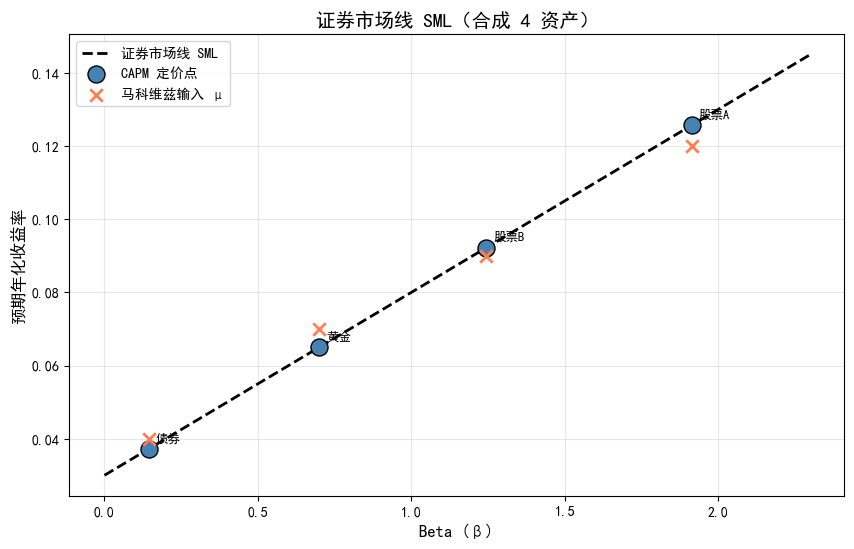

In [1]:
# ===================== Part 1：合成截面 CAPM =====================
# 目标：用数学定义直接算 β（不经过回归），展示 CAPM 定价方程在 SML 图上的表现。
#       这部分的数学对应理论表第一行：
#         β_i = Cov(R_i, R_m) / Var(R_m)               —— 理论 Beta
#         E[R_i] = r_f + β_i × (E[R_m] - r_f)          —— CAPM 定价方程

import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
# ---- 中文字体设置 ----
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---- 资产参数（与马科维兹笔记完全一致，保持学习连贯性） ----
asset_labels = ['股票A', '股票B', '债券', '黄金']
mus = np.array([0.12, 0.09, 0.04, 0.07])       # 年化预期收益率 ← 各资产的"平均一年赚多少"
sigmas = np.array([0.25, 0.18, 0.06, 0.15])    # 年化标准差   ← 各资产的"一年波动多大"
# 相关系数矩阵：刻画两两资产之间的"同涨同跌"程度（1=完全同步，0=无关，-1=完全反向）
rho_matrix = np.array([
    [1.00, 0.70, 0.20, 0.30],
    [0.70, 1.00, 0.10, 0.20],
    [0.20, 0.10, 1.00, 0.05],
    [0.30, 0.20, 0.05, 1.00],
])
# 协方差矩阵 = 各资产标准差的外积 × 相关系数矩阵
# 公式：Cov(i,j) = σ_i × σ_j × ρ_ij
cov_matrix = np.outer(sigmas, sigmas) * rho_matrix

# ---- 无风险利率和市场组合 ----
rf = 0.03  # 无风险利率 3%（马科维兹笔记用 0，这里更贴近真实）
# 市场组合用等权（教学简化；真实 CAPM 里是市值加权的全市场组合）
w_m = np.ones(4) / 4                              # 市场组合权重：每人 25%
mu_m = w_m @ mus                                   # 市场组合预期收益 = Σ(权重 × 各资产收益)
sigma_m = np.sqrt(w_m @ cov_matrix @ w_m)          # 市场组合标准差 = √(w' Σ w)

# ------- 理论 Beta（从协方差矩阵直接算，不经过回归） -------
# 公式：β_i = Cov(R_i, R_m) / Var(R_m)
# 其中 Cov(R_i, R_m) = (Σ · w_m)_i —— 协方差矩阵乘市场权重向量后的第 i 个分量，
# 表示资产 i 与市场组合的协方差
cov_with_market = cov_matrix @ w_m                 # 每行 = 该资产与市场组合的协方差
var_market = w_m @ cov_matrix @ w_m                # 市场组合方差 = w' Σ w
beta_theory = cov_with_market / var_market         # β 向量 = 协方差 / 方差

# ------- CAPM 定价：用 β 反推每个资产的"理论合理收益" -------
# 公式：E[R_i] = r_f + β_i × (E[R_m] - r_f)
market_premium = mu_m - rf                         # 市场风险溢价 = "大盘比无风险多赚的部分"
capm_mu = rf + beta_theory * market_premium        # CAPM 定价的预期收益

# ===================== 验证与输出 =====================
print('=== Part 1：合成截面 CAPM ===')
print(f'市场组合 E[R_m]={mu_m:.4f}, σ_m={sigma_m:.4f}')
print(f'市场风险溢价 E[R_m]-r_f={market_premium:.4f}')
print('\n理论 Beta 与 CAPM 定价收益：')
for i, name in enumerate(asset_labels):
    print(f'  {name}: β={beta_theory[i]:.4f}, CAPM μ={capm_mu[i]:.4f}, 输入 μ={mus[i]:.4f}')

# 输入 μ 来自马科维兹例子，未必满足 CAPM 均衡
# CAPM 定价 μ 和原始输入 μ 的差异说明：并非任意一组给定的 μ 都处于 CAPM 均衡
max_dev = np.max(np.abs(capm_mu - mus))
print(f'\n|CAPM μ - 输入 μ| 最大偏差: {max_dev:.4f}')
print('（偏差>0 说明任意给定的 μ 不一定处于 CAPM 均衡；SML 图用 CAPM μ 作纵轴）')

# ===================== SML 图 =====================
# 证券市场线的画法：取一系列 β 值（0 到最大 β × 1.2），用 CAPM 方程算出对应的预期收益
beta_line = np.linspace(0, beta_theory.max() * 1.2, 100)   # β 横轴范围
sml_line = rf + beta_line * market_premium                  # SML 纵轴 = r_f + β × 市场溢价

plt.figure(figsize=(10, 6))
# 黑色虚线 = 理论 SML（在它上面的点"超额完成任务"，下面的点"对不起风险"）
plt.plot(beta_line, sml_line, 'k--', linewidth=2, label='证券市场线 SML')
# 蓝点 = CAPM 定价后的预期收益（必然落在 SML 线上，因为是用 SML 算的）
plt.scatter(beta_theory, capm_mu, s=150, c='steelblue', edgecolors='black',
            zorder=5, label='CAPM 定价点')
# 红叉 = 马科维兹输入 μ（可能偏离 SML——因为原来的 μ 是随便设的，不一定满足均衡）
plt.scatter(beta_theory, mus, s=80, c='coral', marker='x', linewidths=2,
            zorder=5, label='马科维兹输入 μ')
for i, name in enumerate(asset_labels):
    plt.annotate(name, (beta_theory[i], capm_mu[i]),
                 textcoords='offset points', xytext=(5, 5), fontsize=9)
plt.xlabel('Beta (β)', fontsize=12)
plt.ylabel('预期年化收益率', fontsize=12)
plt.title('证券市场线 SML（合成 4 资产）', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

=== Part 2：理论 β vs OLS 回归 β ===
 资产      理论β     OLSβ     |Δβ|  OLSα(日化)
股票A 1.912882 1.923016 0.010134 -0.000197
股票B 1.243683 1.248014 0.004331  0.000064
 债券 0.143665 0.150767 0.007102  0.000063
 黄金 0.699770 0.678203 0.021567  0.000070

最大 |Δβ| = 2.16e-02
解读：T=5000 大样本下，理论 β 和 OLS β 几乎一致（|Δβ| 极小）；α 也接近 0。


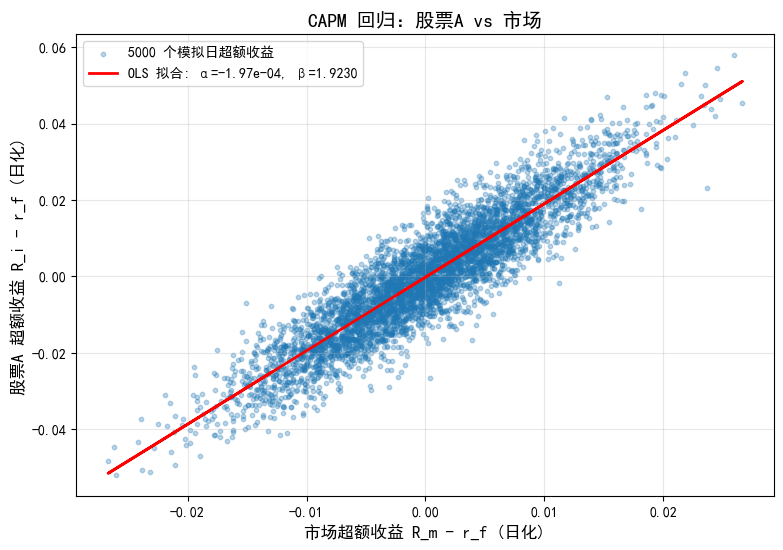

In [2]:
# ===================== Part 2：合成时间序列 + OLS 回归 =====================
# 目标：用模拟数据验证"OLS 回归的 β 在大样本下收敛于理论 β"。
#       联系理论表第四行：R_i - r_f = α + β × (R_m - r_f) + ε
#       其中 α 是截距（理论上 α=0，CAPM 认为多解释不了的部分应该是 0），
#       β 就是我们要估计的市场敏感度。
#       用大样本（T=5000）来验证大数定律：OLS 的 β_ols ≈ β_theory。

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm   # OLS 回归库：sm.OLS(y, X).fit() 做最小二乘
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---- 模拟参数 ----
np.random.seed(42)              # 固定随机种子，保证每次运行结果相同
T = 5000                         # 模拟天数（约 20 年日频）；样本越大，OLS 越准确
n_assets = 4                     # 与 Part 1 的 4 个资产一致
rf_daily = rf / 252              # 日化无风险利率 ≈ 年化 rf ÷ 252 个交易日

# 日化均值与协方差（假设每日 iid 正态）
# 年化 → 日化：μ_daily = μ/252, Σ_daily = Σ/252（iid 假设下近似）
mu_daily = mus / 252
cov_daily = cov_matrix / 252

# ---- 模拟日收益 ----
# np.random.multivariate_normal 生成 (T, n_assets) 的多元正态矩阵
# 每天的收益满足"4 个资产之间的相关性（协方差矩阵）"
returns = np.random.multivariate_normal(mu_daily, cov_daily, size=T)
market_ret = returns @ w_m      # 市场组合日收益 = Σ(权重 × 各资产收益)

# ---- 超额收益（R_i - r_f）—— CAPM 回归的两端都是超额收益 ----
excess_m = market_ret - rf_daily           # 市场超额收益 = R_m - r_f → 回归的 X（解释变量）
excess_assets = returns - rf_daily         # 各资产超额收益 = R_i - r_f → 回归的 y（被解释变量）

# ---- 逐只股票做 OLS 回归求 β 和 α ----
# β_ols：OLS 估计的市场敏感度，应该接近理论 β
# α_ols：OLS 估计的截距（Jensen's Alpha），CAPM 预测它应该为 0
# sm.add_constant(excess_m) 在 X 左边加一列全 1，作为截距项的系数
beta_ols_list = []
alpha_ols_list = []
for i in range(n_assets):
    X = sm.add_constant(excess_m)                         # X = [1, R_m - r_f]，两列
    model = sm.OLS(excess_assets[:, i], X).fit()          # 做 OLS 回归
    alpha_ols_list.append(model.params[0])                # α = 截距（params[0] 对应常数项）
    beta_ols_list.append(model.params[1])                 # β = 斜率（params[1] 对应市场超额收益）

beta_ols = np.array(beta_ols_list)      # OLS 估计的 β
alpha_ols = np.array(alpha_ols_list)    # OLS 估计的 α（日化）

# ---- 理论 vs OLS 对比表 ----
# |理论β - OLSβ| 应该是很小的数（大样本下收敛）
compare_df = pd.DataFrame({
    '资产': asset_labels,
    '理论β': beta_theory,       # Part 1 用公式直接算的
    'OLSβ': beta_ols,           # Part 2 用模拟数据回归出来的
    '|Δβ|': np.abs(beta_theory - beta_ols),  # 差异的绝对值
    'OLSα(日化)': alpha_ols,    # Jensen's α（日频尺度下理论上应为 0）
})
print('=== Part 2：理论 β vs OLS 回归 β ===')
print(compare_df.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print(f'\n最大 |Δβ| = {compare_df["|Δβ|"].max():.2e}')
print('解读：T=5000 大样本下，理论 β 和 OLS β 几乎一致（|Δβ| 极小）；α 也接近 0。')

# ---- 散点图：展示回归拟合线（以股票A为例） ----
i_show = 0       # 选择资产 0（股票A）演示
X = sm.add_constant(excess_m)
model_show = sm.OLS(excess_assets[:, i_show], X).fit()
fit_line = model_show.predict(X)  # 拟合值 = α + β × (R_m - r_f)

plt.figure(figsize=(9, 6))
plt.scatter(excess_m, excess_assets[:, i_show], alpha=0.3, s=10,
            label=f'{T} 个模拟日超额收益')
plt.plot(excess_m, fit_line, 'r-', linewidth=2,
         label=f'OLS 拟合: α={model_show.params[0]:.2e}, β={model_show.params[1]:.4f}')
plt.xlabel('市场超额收益 R_m - r_f (日化)', fontsize=12)
plt.ylabel(f'{asset_labels[i_show]} 超额收益 R_i - r_f (日化)', fontsize=12)
plt.title(f'CAPM 回归：{asset_labels[i_show]} vs 市场', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# 图解读：每个灰点 = 一天的 (市场超额, 资产超额)；红线 = OLS 拟合线；
#         斜率就是 β（市场涨 1%，股票平均跟着涨 β%）；红线过原点说明 α≈0。

In [3]:
# ===================== Part 3：真实 A 股数据准备 =====================
# 目标：从本地 Parquet 数据（my_utils.fun.read_day_data）读取选定的几只大盘蓝筹日线，
#       并获取沪深300指数作为市场组合，转换为周频收益率 & 超额收益率。
# 注意：延迟导入掘金 API（放在 try/except 里），确保 Part 1/2 即使没装掘金也能独立运行。

import sys
import os
from datetime import date
import numpy as np
import pandas as pd
import polars as pl              # 本地数据的默认格式（fun.py 返回 Polars DataFrame）
import warnings
warnings.filterwarnings('ignore')

# ---- 项目根目录定位（与 FF3/FF5/Barra 笔记一致） ----
PROJECT_ROOT = None
for _candidate in [os.getcwd(), os.path.join(os.getcwd(), '..'), os.path.join(os.getcwd(), '../..')]:
    _root = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_root, 'my_utils')):
        PROJECT_ROOT = _root
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('未找到项目根目录（需包含 my_utils 文件夹）')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from my_utils.fun import read_day_data   # 本地日线 Parquet 读取接口

# ---- 参数设置 ----
start_date = date(2022, 1, 1)
end_date = date(2025, 12, 31)
rf_annual = 0.02              # 年化无风险利率 2%（教学用常数）
rf_weekly = rf_annual / 52    # 周无风险利率

# ---- 选股：大盘蓝筹（掘金 GM 代码格式），固定列表，避免全市场扫描 ----
stock_list = [
    'SHSE.600519',  # 贵州茅台—白酒龙头，大消费
    'SHSE.600036',  # 招商银行—银行龙头
    'SHSE.601318',  # 中国平安—保险龙头
    'SZSE.300750',  # 宁德时代—新能源龙头（创业板，深圳交易所）
    'SHSE.601398',  # 工商银行—全球最大银行
    'SHSE.600028',  # 中国石化—石化龙头
    'SHSE.601857',  # 中国石油—石油龙头
]
stock_names = {
    'SHSE.600519': '贵州茅台', 'SHSE.600036': '招商银行',
    'SHSE.601318': '中国平安', 'SZSE.300750': '宁德时代',
    'SHSE.601398': '工商银行', 'SHSE.600028': '中国石化',
    'SHSE.601857': '中国石油',
}

# ---- 从本地 Parquet 读取日线数据 ----
# read_day_data 返回 Polars DataFrame，内部走 parquet 扫描，比 pandas read_csv 快得多
print('=== Part 3：读取真实 A 股日线 ===')
stock_pl = read_day_data(
    start_date, end_date,
    stock_list=stock_list,
    fields=['code', 'trading_date', 'close', 'pre_close', 'name'],
)

# ---- 计算日收益率 ----
# 优先用 pre_close（前收盘），能避免送股/拆股导致的前后价格断裂
# .when().then().otherwise() 是 Polars 的条件表达式链
# pct_change().over('code')：每组股票按 code 分组，分别计算涨跌幅
stock_pl = stock_pl.sort(['code', 'trading_date']).with_columns([
    pl.when(pl.col('pre_close').is_not_null() & (pl.col('pre_close') != 0))
    .then(pl.col('close') / pl.col('pre_close') - 1)        # 有 pre_close：用比值
    .otherwise(pl.col('close').pct_change().over('code'))   # 无 pre_close：退化为组内 pct_change
    .alias('daily_ret'),
])
stock_pd = stock_pl.to_pandas()                         # 转 pandas 以便后续 groupby/resample 周频聚合
stock_pd['trading_date'] = pd.to_datetime(stock_pd['trading_date'])

# ---- 转为周收益率 ----
# 做法：每周最后一个交易日 → 用该周所有日收益的复合 = Π(1+r_t) - 1
weekly_stock = (
    stock_pd.set_index('trading_date')
    .groupby('code')['daily_ret']
    .resample('W')                                      # 按周重采样（默认周日）
    .apply(lambda x: (1 + x).prod() - 1 if len(x) > 0 else np.nan)
    .reset_index()
    .rename(columns={'daily_ret': 'weekly_ret'})
)
weekly_stock = weekly_stock.dropna(subset=['weekly_ret'])

# ---- 获取沪深300指数作为市场基准 ----
# 延迟导入 my_utils.stock_api（内部封装了掘金 GM 接口），
# 这样如果只是看 Part 1/2 的理论演示，不装掘金也能跑。
# 如果 API 失败（无权限/无网络），自动降级为"所选股票等权组合"作为伪市场。
market_source = '沪深300 (SHSE.000300)'
try:
    from my_utils.stock_api import stock_api
    api = stock_api()
    index_data = api.gm_get_index_day_data(
        index_code='SHSE.000300',                       # 沪深300 指数代码
        start_date=start_date.strftime('%Y-%m-%d'),
        end_date=end_date.strftime('%Y-%m-%d'),
    )
    index_pd = index_data.copy()
    index_pd['trading_date'] = pd.to_datetime(index_pd['trading_date'])
    index_pd['daily_ret'] = index_pd['close'].pct_change()  # 指数日收益
    # 周度复合收益
    weekly_market = (
        index_pd.set_index('trading_date')['daily_ret']
        .resample('W')
        .apply(lambda x: (1 + x.dropna()).prod() - 1 if x.notna().any() else np.nan)
        .reset_index()
        .rename(columns={'daily_ret': 'weekly_ret'})
    )
    weekly_market = weekly_market.dropna(subset=['weekly_ret'])
    print(f'市场基准: {market_source}, 周数={len(weekly_market)}')
except Exception as e:
    # 降级方案：用所选股票的等权组合替代（最简 CAMP 教学演示够用）
    market_source = '等权股票组合（降级）'
    print(f'指数 API 失败 ({e})，降级为等权市场组合')
    pivot = weekly_stock.pivot(index='trading_date', columns='code', values='weekly_ret')
    weekly_market = pd.DataFrame({
        'trading_date': pivot.index,
        'weekly_ret': pivot.mean(axis=1),              # 所有股票的平均收益 = 等权市场
    }).reset_index(drop=True)

# ---- 对齐：只保留股票和市场都有数据的周 ----
weekly_stock = weekly_stock.merge(
    weekly_market[['trading_date', 'weekly_ret']].rename(columns={'weekly_ret': 'market_weekly_ret'}),
    on='trading_date',
    how='inner',                                        # 内连接：只保留共有的周
)
# 超额收益 = 各资产收益 - 周无风险利率（对应理论表：R_i - r_f）
weekly_stock['excess_ret'] = weekly_stock['weekly_ret'] - rf_weekly
weekly_stock['excess_market'] = weekly_stock['market_weekly_ret'] - rf_weekly

print(f'股票数={weekly_stock["code"].nunique()}, 对齐后周数={weekly_stock["trading_date"].nunique()}')
print(f'市场数据来源: {market_source}')
weekly_stock.head()

=== Part 3：读取真实 A 股日线 ===


市场基准: 沪深300 (SHSE.000300), 周数=204
股票数=7, 对齐后周数=204
市场数据来源: 沪深300 (SHSE.000300)


,code,trading_date,weekly_ret,market_weekly_ret,excess_ret,excess_market
0,SHSE.600028,2022-01-09,0.02836879,-0.01939824,0.02798418,-0.01978286
1,SHSE.600028,2022-01-16,-0.02298851,-0.01983195,-0.02337312,-0.02021657
2,SHSE.600028,2022-01-23,0.00941176,0.01112439,0.00902715,0.01073977
3,SHSE.600028,2022-01-30,-0.02331002,-0.04509894,-0.02369464,-0.04548356
4,SHSE.600028,2022-02-13,0.07398568,0.00824406,0.07360106,0.00785944


In [4]:
# ===================== Part 4：真实数据 OLS 估 Beta =====================
# 目标：对每只 A 股大蓝筹做 CAPM 回归，估计其 β（市场敏感度）和 α（Jensen's Alpha）。
#
# 回归方程：R_i^e = α + β × R_m^e + ε
#   其中 R_i^e = R_i - r_f（个股超额收益，周频）
#         R_m^e = R_m - r_f（市场超额收益，周频）
#         α = Jensen's Alpha，截距（如果 CAPM 正确，α 应该接近 0）
#         β = 市场敏感度，斜率

import statsmodels.api as sm
import pandas as pd
import numpy as np

results = []
# 按股票代码分组，每只股票独立跑一次 CAPM 回归
for code, grp in weekly_stock.groupby('code'):
    grp = grp.dropna(subset=['excess_ret', 'excess_market'])  # 去掉缺失值
    if len(grp) < 20:                 # 防御：样本太少（< 20 周）不做回归，统计量不可靠
        continue
    y = grp['excess_ret'].values      # 被解释变量 y = 个股超额收益 = R_i - r_f
    X = sm.add_constant(grp['excess_market'].values)  # 解释变量 X = [1, R_m - r_f]
    model = sm.OLS(y, X).fit()        # 普通最小二乘回归

    # 年化平均收益：周收益均值 × 52（简单年化，忽略复利）
    realized_mu = grp['weekly_ret'].mean() * 52

    results.append({
        'code': code,
        'name': stock_names.get(code, code),
        'beta_ols': model.params[1],          # β = OLS 回归的斜率系数 → 对应理论表的 β_i
        'alpha_ols': model.params[0],         # α = OLS 回归的截距 → 对应理论表的 Jensen's α（周频）
        'alpha_annual': model.params[0] * 52, # 年化 α（近似，周频 × 52）
        'r_squared': model.rsquared,          # R² = 市场能解释这只股票波动的比例
        'pvalue_beta': model.pvalues[1],      # β 的 p 值 → H0: β=0，p<0.05 说明 β 显著不为 0
        'pvalue_alpha': model.pvalues[0],     # α 的 p 值 → H0: α=0，p<0.05 说明 α 显著偏离 0
        'realized_mu': realized_mu,           # 年化实际平均收益
        'n_weeks': len(grp),                  # 样本周数
    })

capm_results = pd.DataFrame(results)
print('=== Part 4：真实 A 股 CAPM 回归结果 ===')
print(capm_results.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print(f'\n成功估计 β 的股票数: {len(capm_results)}')
capm_results

=== Part 4：真实 A 股 CAPM 回归结果 ===
       code name  beta_ols  alpha_ols  alpha_annual  r_squared  pvalue_beta  pvalue_alpha  realized_mu  n_weeks
SHSE.600028 中国石化    0.2824     0.0032        0.1674     0.0612       0.0004        0.0864       0.1816      204
SHSE.600036 招商银行    0.9153     0.0008        0.0418     0.4189       0.0000        0.6592       0.0429      204
SHSE.600519 贵州茅台    1.1797    -0.0006       -0.0297     0.5571       0.0000        0.7480      -0.0342      204
SHSE.601318 中国平安    1.0907     0.0032        0.1656     0.5203       0.0000        0.0735       0.1630      204
SHSE.601398 工商银行    0.2035     0.0037        0.1942     0.0506       0.0012        0.0130       0.2100      204
SHSE.601857 中国石油    0.4065     0.0053        0.2743     0.0625       0.0003        0.0488       0.2859      204
SZSE.300750 宁德时代    1.3575     0.0024        0.1238     0.3876       0.0000        0.4101       0.1157      204

成功估计 β 的股票数: 7


,code,name,beta_ols,alpha_ols,alpha_annual,r_squared,pvalue_beta,pvalue_alpha,realized_mu,n_weeks
0,SHSE.600028,中国石化,0.28239916,0.00321966,0.16742231,0.06121253,3.60185628e-04,0.08641883,0.18157582,204
1,SHSE.600036,招商银行,0.91531993,0.00080450,0.04183375,0.41885862,1.34044656e-25,0.65923893,0.04288395,204
2,SHSE.600519,贵州茅台,1.17973938,-0.00057179,-0.02973299,0.55710361,1.41448502e-37,0.74800296,-0.03415704,204
3,SHSE.601318,中国平安,1.09074486,0.00318440,0.16558854,0.52025535,4.68490944e-34,0.07346006,0.16300694,204
4,SHSE.601398,工商银行,0.20354982,0.00373423,0.19417986,0.05058245,1.22032051e-03,0.01299512,0.20996578,204
5,SHSE.601857,中国石油,0.40653277,0.00527554,0.27432826,0.06247643,3.11547766e-04,0.04876451,0.28591184,204
6,SZSE.300750,宁德时代,1.35745513,0.00237993,0.12375656,0.38755707,2.78538484e-23,0.41010514,0.11565327,204


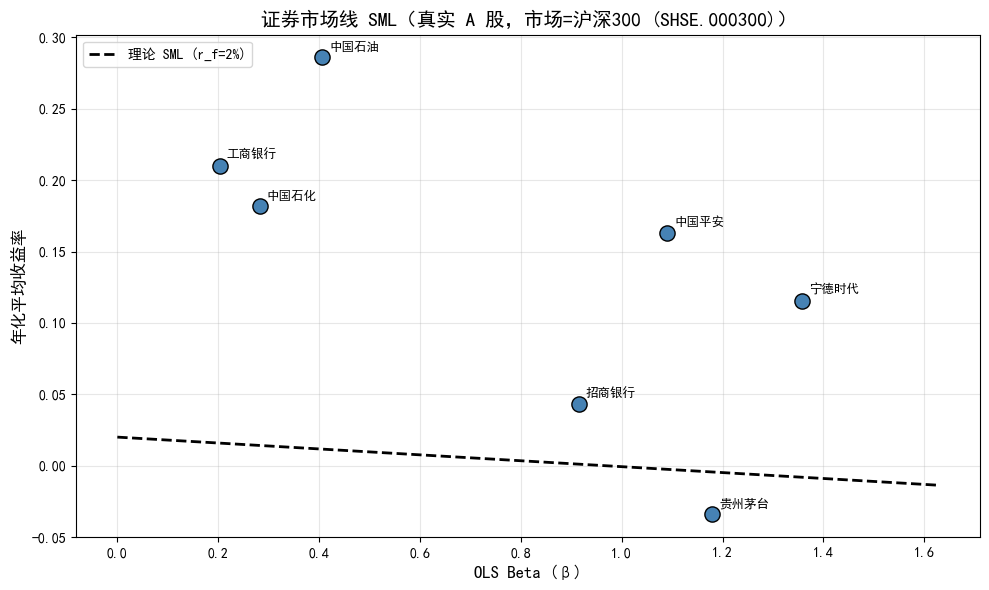

=== Part 5：Jensen's α 解读 ===
样本期年化市场风险溢价 ≈ -2.07%
  中国石化: β=0.28 (β<1 波动小于市场), α不显著, R²=0.06
  招商银行: β=0.92 (β<1 波动小于市场), α不显著, R²=0.42
  贵州茅台: β=1.18 (β>1 波动大于市场), α不显著, R²=0.56
  中国平安: β=1.09 (β>1 波动大于市场), α不显著, R²=0.52
  工商银行: β=0.20 (β<1 波动小于市场), α显著为正, R²=0.05
  中国石油: β=0.41 (β<1 波动小于市场), α显著为正, R²=0.06
  宁德时代: β=1.36 (β>1 波动大于市场), α不显著, R²=0.39


In [5]:
# ===================== Part 5：SML 可视化与 Jensen's α 解读 =====================
# 目标：把真实 A 股数据画在 SML 图上，看每只股票是在 SML 线的上方（超预期）
# 还是下方（达不到预期），并用 Jensen's α 的显著性来辅助判断。

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# ---- 市场风险溢价（用样本期内市场超额收益的均值估计） ----
# 市场风险溢价 = mean(R_m - r_f)（周频） × 52（年化）
market_premium_weekly = weekly_stock['excess_market'].mean()   # 周均超额收益
market_premium_annual = market_premium_weekly * 52             # 年化市场风险溢价

# ---- 画 SML 线 ----
# 理论 SML：E[R_i] = r_f + β × (E[R_m] - r_f)
beta_range = np.linspace(0, capm_results['beta_ols'].max() * 1.2, 100)
sml_real = rf_annual + beta_range * market_premium_annual

fig, ax = plt.subplots(figsize=(10, 6))
# 黑色虚线 = 用样本估计的市场风险溢价画出的 SML
ax.plot(beta_range, sml_real, 'k--', linewidth=2, label=rf'理论 SML (r_f={rf_annual:.0%})')
# 蓝点 = 各股票的实际年化收益 vs β
#   点在线上方 = 实际收益 > CAPM 预测 → α>0（超额完成任务）
#   点在线下方 = 实际收益 < CAPM 预测 → α<0（没能达到风险该有的回报）
ax.scatter(
    capm_results['beta_ols'], capm_results['realized_mu'],
    s=120, c='steelblue', edgecolors='black', zorder=5,
)
for _, row in capm_results.iterrows():
    ax.annotate(
        row['name'],
        (row['beta_ols'], row['realized_mu']),
        textcoords='offset points', xytext=(5, 5), fontsize=9,
    )
ax.set_xlabel('OLS Beta (β)', fontsize=12)
ax.set_ylabel('年化平均收益率', fontsize=12)
ax.set_title(f'证券市场线 SML（真实 A 股，市场={market_source}）', fontsize=14)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---- Jensen's α 解读 ----
# α(年化) > 0 且显著：这只股票在 CAPM 框架下"超额完成任务"——实际收益高于 β 应该给的。
# α(年化) < 0 且显著：这只股票"对不起它的风险"——承担了 β 水平的风险却没拿到对应的回报。
# α 不显著：这只股票的表现和 CAPM 预测一致——收益刚好是 β 该值的。
print('=== Part 5：Jensen\'s α 解读 ===')
print(f'样本期年化市场风险溢价 ≈ {market_premium_annual:.2%}')
for _, row in capm_results.iterrows():
    beta_tag = 'β>1 波动大于市场' if row['beta_ols'] > 1 else 'β<1 波动小于市场'
    if row['pvalue_alpha'] < 0.05 and row['alpha_annual'] > 0:
        alpha_tag = 'α显著为正'
    elif row['pvalue_alpha'] < 0.05 and row['alpha_annual'] < 0:
        alpha_tag = 'α显著为负'
    else:
        alpha_tag = 'α不显著'
    print(f"  {row['name']}: β={row['beta_ols']:.2f} ({beta_tag}), {alpha_tag}, R²={row['r_squared']:.2f}")

## 四、学习小结

1. **Part 1（合成截面）**：给定协方差矩阵，可用 $\beta_i=\text{Cov}(R_i,R_m)/\text{Var}(R_m)$ 直接算理论 β；CAPM 定价点必然落在 SML 上，但马科维兹笔记里任意给定的 μ 不一定满足 CAPM 均衡。
2. **Part 2（合成时序）**：大样本 OLS 回归的 β 收敛于理论值；α 应接近 0（日化尺度下很小）。
3. **Part 3–5（真实 A 股）**：β>1 表示波动大于市场；Jensen's α 显著说明收益偏离 CAPM 预测（可能来自个股特质风险、因子暴露等）。
4. **与马科维兹的联系**：马科维兹告诉我们「组合」如何分散非系统性风险；CAPM 进一步说，均衡时投资者只承担系统性风险（β），并据此获得风险溢价。

### 📖 小结通俗版

- **CAPM 的核心公式就一句话**：一只股票的预期收益 = 无风险利率 + β × 市场风险溢价。你承担多少市场风险（β），就该拿多少超额回报。
- **SML 图怎么看**：点在线上 = "风险和回报匹配"。点在线上方 = 这只股票赚得比它的风险该赚的多（可能是基金经理选股能力强，也可能只是侥幸）。线下方 = 赚少了，不划算。
- **β 怎么来的**：两种方式——① 用协方差/方差直接算（Part 1），② 用历史收益跑 OLS 回归（Part 2/4）。两者在大样本下是一致的。新手记住"OLS 回归的斜率就是 β"就够了。
- **α 有什么用**：α 是 CAPM 的"漏网之鱼"——如果 CAPM 是对的，α 应该等于 0。所以 α 显著不为零，要么说明你选到了好股（或烂股），要么说明 CAPM 本身不够用（漏了其他因子）——这就是 [[fama_french.ipynb]] 要解决的问题。

**下一步**：[fama_french.ipynb](fama_french.ipynb) 在 CAPM 的单因子基础上加入规模(SMB)和价值(HML)，用三个因子来解释 CAPM 漏掉的收益。